# Apriori Laptops

## Librerias

In [4]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import networkx as nx

## Clases

In [5]:
from src.utils import path

# Lectura de DF procesado

In [6]:
directorio_proyecto = path.obtener_ruta_local()
datos = pd.read_csv(directorio_proyecto+'\\data\\procesed\\datos_laptos.csv',delimiter = ',',decimal = ".", encoding='utf-8')
datos.head()

,Nombre,Paquete de Ventas,Caracteristicas
0,ASUS ROG Strix SCAR 17 Core i9 12th Gen - (32 ...,"Laptop, Power Adaptor, User Guide, Warranty Do...","Off Black,Gaming Laptop,Gaming,Intel,Core i9,3..."
1,ASUS ROG Strix SCAR 15 Core i9 12th Gen - (32 ...,"Laptop, Power Adaptor, User Guide, Warranty Do...","Off Black,Gaming Laptop,Gaming,Intel,Core i9,3..."
2,HP Victus Ryzen 7 Octa Core 5800H - (16 GB/512...,"Laptop, battery, adapter, cables and user manuals","Mica Silver,Gaming Laptop,Gaming,AMD,Ryzen 7 O..."
3,Lenovo IdeaPad Gaming 3i Ryzen 7 Octa Core R7-...,"Laptop, Power Adaptor, User Guide, Warranty Do...","Shadow Black,Gaming Laptop,Gaming,AMD,Ryzen 7 ..."
4,Lenovo Yoga Slim 7 Core i5 11th Gen - (16 GB/5...,"Laptop, Adaptor","Slate Grey,Thin and Light Laptop,Processing & ..."


## Apriori con columna Paquete de Ventas

In [7]:
df_paquete_ventas = datos[["Paquete de Ventas"]]
df_paquete_ventas.head()

,Paquete de Ventas
0,"Laptop, Power Adaptor, User Guide, Warranty Do..."
1,"Laptop, Power Adaptor, User Guide, Warranty Do..."
2,"Laptop, battery, adapter, cables and user manuals"
3,"Laptop, Power Adaptor, User Guide, Warranty Do..."
4,"Laptop, Adaptor"


In [8]:
df_paquete_ventas.shape

(984, 1)

In [9]:
print(df_paquete_ventas.columns.tolist())

['Paquete de Ventas']


In [10]:
data = list(df_paquete_ventas["Paquete de Ventas"].apply(lambda x:x.split(",") ))
data

[['Laptop', ' Power Adaptor', ' User Guide', ' Warranty Documents'],
 ['Laptop', ' Power Adaptor', ' User Guide', ' Warranty Documents'],
 ['Laptop', ' battery', ' adapter', ' cables and user manuals'],
 ['Laptop', ' Power Adaptor', ' User Guide', ' Warranty Documents'],
 ['Laptop', ' Adaptor'],
 ['Thin & Light Laptop',
  ' Power Adaptor',
  ' User Guide',
  ' Warranty Documents'],
 ['Laptop & Adaptor'],
 ['2 in 1 Laptop', ' Power Adaptor', ' User Guide', ' Warranty Documents'],
 ['Laptop ', ' Adaptor', ' & Manual'],
 ['Laptop', ' battery', ' adapter', ' cables and user manuals'],
 ['Laptop', ' battery', ' adapter', ' cables and user manuals'],
 ['Laptop', ' battery', ' adapter', ' cables and user manuals'],
 ['2 in 1 Laptop', ' Power Adaptor', ' User Guide', ' Warranty Documents'],
 ['Laptop', ' Manual', ' Adaptor'],
 ['Laptop', ' Manual', ' Adaptor'],
 ['Laptop',
  ' Power Adaptor',
  ' User Guide',
  ' GV 301 Sleeve Bag',
  ' Pen',
  ' Warranty Documents'],
 ['Laptop',
  ' Battery',

In [11]:
a = TransactionEncoder()
a_data = a.fit(data).transform(data)
df = pd.DataFrame(a_data,columns=a.columns_)
df = df.replace(False,0)
df

,& Manual,1 Power Adaptor,1 Power cord,1 Stylus,1 x Adapter,1 x User Instruction Book,1U USB C Type DC Power Adapter,1U USB-C LAN Adapter,30 W USB-C Power Adapter,61 W USB-C Power Adapter,...,Lapyop,MacBook Air,MacBook Pro,TYPE-C Power Adaptor,Thin & Light Laptop,USB C to USB A converter,User Manual,User guide and Manuals,laptop,sales_package Laptop
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
979,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
980,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
981,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
982,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
df.shape

(984, 122)

In [13]:
#establezca un valor umbral para el valor de soporte y calcule el valor de soporte.
df = apriori(df, min_support = 0.5, use_colnames = True, verbose = 1)
df

Processing 4 combinations | Sampling itemset size 43


C:\Users\pmari\OneDrive\Para Revisar\Documentos\GitKraken\ReglasAsociacion\.venv\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.569106,frozenset({ Power Adaptor})
1,0.642276,frozenset({ User Guide})
2,0.551829,frozenset({ Warranty Documents})
3,0.926829,frozenset({Laptop})
4,0.563008,"frozenset({ User Guide, Power Adaptor})"
5,0.5,"frozenset({ Power Adaptor, Warranty Documents})"
6,0.549797,"frozenset({Laptop, Power Adaptor})"
7,0.551829,"frozenset({ User Guide, Warranty Documents})"
8,0.611789,"frozenset({ User Guide, Laptop})"
9,0.521341,"frozenset({Laptop, Warranty Documents})"


In [14]:
#Veamos nuestros valores de interpretación usando la función de regla asociativa.
df_ar = association_rules(df, metric = "confidence", min_threshold = 0.5)
df_ar

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({ User Guide}),frozenset({ Power Adaptor}),0.642276,0.569106,0.563008,0.876582,1.540280,1.0,0.197485,3.491349,0.980555,0.868339,0.713578,0.932934
1,frozenset({ Power Adaptor}),frozenset({ User Guide}),0.569106,0.642276,0.563008,0.989286,1.540280,1.0,0.197485,33.387534,0.814045,0.868339,0.970049,0.932934
2,frozenset({ Power Adaptor}),frozenset({ Warranty Documents}),0.569106,0.551829,0.500000,0.878571,1.592107,1.0,0.185951,3.690818,0.863092,0.805237,0.729057,0.892324
3,frozenset({ Warranty Documents}),frozenset({ Power Adaptor}),0.551829,0.569106,0.500000,0.906077,1.592107,1.0,0.185951,4.587757,0.829821,0.805237,0.782029,0.892324
4,frozenset({Laptop}),frozenset({ Power Adaptor}),0.926829,0.569106,0.549797,0.593202,1.042340,1.0,0.022333,1.059233,0.555145,0.581096,0.055921,0.779637
5,frozenset({ Power Adaptor}),frozenset({Laptop}),0.569106,0.926829,0.549797,0.966071,1.042340,1.0,0.022333,2.156611,0.094270,0.581096,0.536310,0.779637
6,frozenset({ User Guide}),frozenset({ Warranty Documents}),0.642276,0.551829,0.551829,0.859177,1.556962,1.0,0.197402,3.182516,1.000000,0.859177,0.685783,0.929589
7,frozenset({ Warranty Documents}),frozenset({ User Guide}),0.551829,0.642276,0.551829,1.000000,1.556962,1.0,0.197402,inf,0.798186,0.859177,1.000000,0.929589
8,frozenset({ User Guide}),frozenset({Laptop}),0.642276,0.926829,0.611789,0.952532,1.027732,1.0,0.016508,1.541463,0.075430,0.639066,0.351266,0.806310
9,frozenset({Laptop}),frozenset({ User Guide}),0.926829,0.642276,0.611789,0.660088,1.027732,1.0,0.016508,1.052400,0.368771,0.639066,0.049791,0.806310


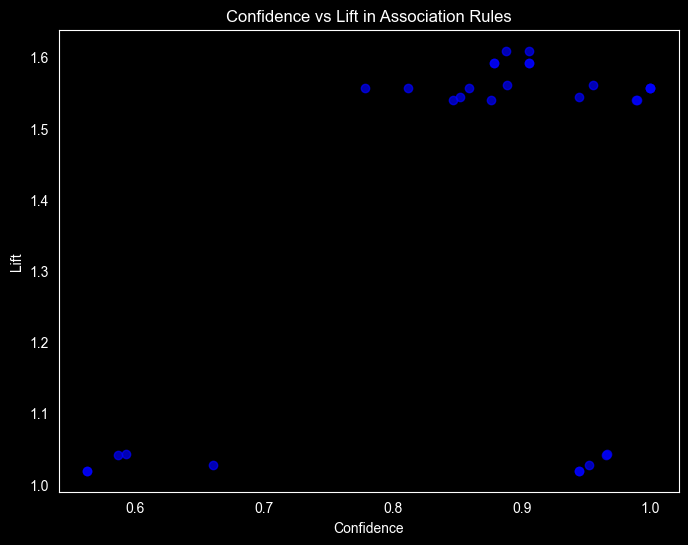

In [15]:
# Scatter plot of confidence vs lift
plt.figure(figsize=(8,6))
plt.scatter(df_ar['confidence'], df_ar['lift'], alpha=0.7, color='b')
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.title('Confidence vs Lift in Association Rules')
plt.grid()
plt.show()

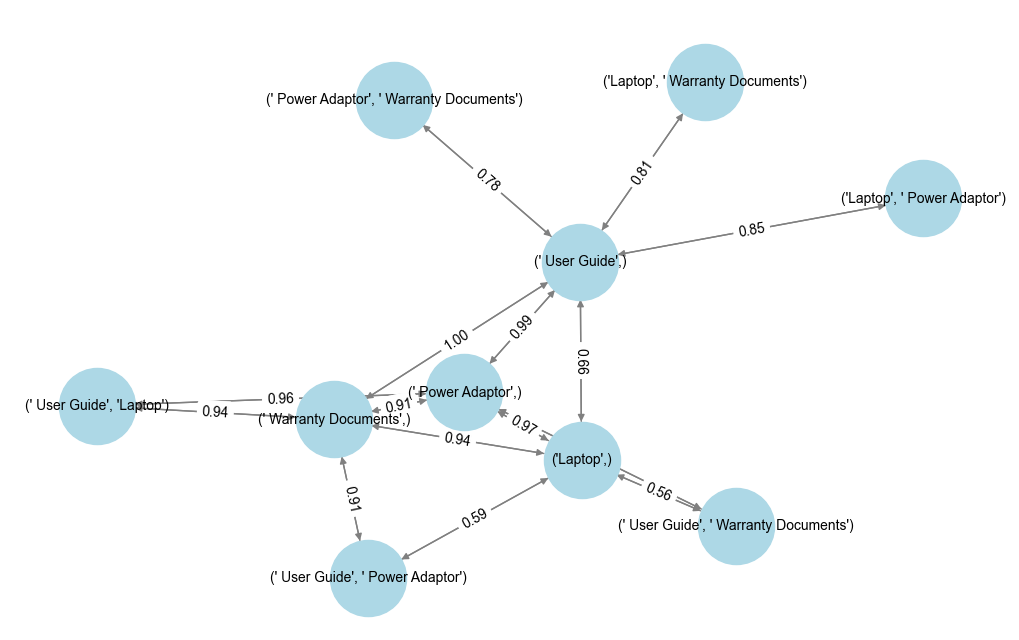

In [16]:
# Visualizing association rules as a network graph
G = nx.DiGraph()
for _, row in df_ar.iterrows():
    G.add_edge(tuple(row['antecedents']), tuple(row['consequents']), weight=row['confidence'])
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=3000, font_size=10)
edge_labels = {(tuple(row['antecedents']), tuple(row['consequents'])): f"{row['confidence']:.2f}"
               for _, row in df_ar.iterrows()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Association Rules Network")
plt.show()

## Apriori con columna Características

In [17]:
df_paquete_caract = datos[["Caracteristicas"]]
df_paquete_caract.head()

,Caracteristicas
0,"Off Black,Gaming Laptop,Gaming,Intel,Core i9,3..."
1,"Off Black,Gaming Laptop,Gaming,Intel,Core i9,3..."
2,"Mica Silver,Gaming Laptop,Gaming,AMD,Ryzen 7 O..."
3,"Shadow Black,Gaming Laptop,Gaming,AMD,Ryzen 7 ..."
4,"Slate Grey,Thin and Light Laptop,Processing & ..."


In [18]:
df_paquete_caract.shape

(984, 1)

In [19]:
data = list(df_paquete_caract["Caracteristicas"].apply(lambda x: x.split(",")))
data

[['Off Black',
  'Gaming Laptop',
  'Gaming',
  'Intel',
  'Core i9',
  '32 GB',
  'DDR5',
  'Windows 11 Home'],
 ['Off Black',
  'Gaming Laptop',
  'Gaming',
  'Intel',
  'Core i9',
  '32 GB',
  'DDR5',
  'Windows 11 Home'],
 ['Mica Silver',
  'Gaming Laptop',
  'Gaming',
  'AMD',
  'Ryzen 7 Octa Core',
  '16 GB',
  'DDR4',
  'Windows 11 Home'],
 ['Shadow Black',
  'Gaming Laptop',
  'Gaming',
  'AMD',
  'Ryzen 7 Octa Core',
  '16 GB',
  'DDR4',
  'Windows 11 Home'],
 ['Slate Grey',
  'Thin and Light Laptop',
  'Processing & Multitasking',
  ' Entertainment',
  ' Everyday Use',
  ' Performance',
  ' Travel & Business',
  'Intel',
  'Core i5',
  '16 GB',
  'DDR4',
  'Windows 11 Home'],
 ['Slate Grey',
  'Thin and Light Laptop',
  'Processing & Multitasking',
  'Intel',
  'Core i7',
  '16 GB',
  'DDR4',
  'Windows 11 Home'],
 ['Iron Grey',
  'Thin and Light Laptop',
  'Everyday Use',
  ' Entertainment',
  ' Travel & Business',
  ' Processing & Multitasking',
  'Intel',
  'Celeron Dual C

In [20]:
a = TransactionEncoder()
a_data = a.fit(data).transform(data)
df = pd.DataFrame(a_data,columns=a.columns_)
df = df.replace(False,0)
df

,Black,Blue,Entertainment,Everyday Use,Gaming,Performance,Processing & Multitasking,Shadow Black,Travel & Business,16 GB,...,Unified Memory,Vintage Gray,Volcano Gray,Volt Green,White,Windows 10,Windows 10 Home,Windows 10 Pro,Windows 11 Home,Windows 11 Pro
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,True,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,True,0
2,0,0,0,0,0,0,0,0,0,True,...,0,0,0,0,0,0,0,0,True,0
3,0,0,0,0,0,0,0,0,0,True,...,0,0,0,0,0,0,0,0,True,0
4,0,0,True,True,0,True,0,0,True,True,...,0,0,0,0,0,0,0,0,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
979,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,True,0,0,0
980,0,0,0,0,0,0,0,0,0,True,...,0,0,0,0,0,0,True,0,0,0
981,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,0,0
982,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
#establezca un valor umbral para el valor de soporte y calcule el valor de soporte.
df = apriori(df, min_support = 0.4, use_colnames = True, verbose = 1)
df

Processing 45 combinations | Sampling itemset size 3


C:\Users\pmari\OneDrive\Para Revisar\Documentos\GitKraken\ReglasAsociacion\.venv\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.566057,frozenset({8 GB})
1,0.868902,frozenset({DDR4})
2,0.711382,frozenset({Intel})
3,0.587398,frozenset({Processing & Multitasking})
4,0.511179,frozenset({Thin and Light Laptop})
5,0.445122,frozenset({Windows 10 Home})
6,0.400407,frozenset({Windows 11 Home})
7,0.537602,"frozenset({8 GB, DDR4})"
8,0.406504,"frozenset({Intel, 8 GB})"
9,0.609756,"frozenset({Intel, DDR4})"


In [22]:
#Veamos nuestros valores de interpretación usando la función de regla asociativa.
df_ar = association_rules(df, metric = "confidence", min_threshold = 0.5)
df_ar

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({8 GB}),frozenset({DDR4}),0.566057,0.868902,0.537602,0.949731,1.093023,1.0,0.045753,2.607905,0.196124,0.599094,0.616550,0.784222
1,frozenset({DDR4}),frozenset({8 GB}),0.868902,0.566057,0.537602,0.618713,1.093023,1.0,0.045753,1.138102,0.649185,0.599094,0.121344,0.784222
2,frozenset({Intel}),frozenset({8 GB}),0.711382,0.566057,0.406504,0.571429,1.009490,1.0,0.003821,1.012534,0.032570,0.466744,0.012379,0.644781
3,frozenset({8 GB}),frozenset({Intel}),0.566057,0.711382,0.406504,0.718133,1.009490,1.0,0.003821,1.023950,0.021663,0.466744,0.023390,0.644781
4,frozenset({Intel}),frozenset({DDR4}),0.711382,0.868902,0.609756,0.857143,0.986466,1.0,-0.008366,0.917683,-0.045378,0.628272,-0.089701,0.779449
5,frozenset({DDR4}),frozenset({Intel}),0.868902,0.711382,0.609756,0.701754,0.986466,1.0,-0.008366,0.967719,-0.094737,0.628272,-0.033358,0.779449
6,frozenset({Processing & Multitasking}),frozenset({DDR4}),0.587398,0.868902,0.496951,0.846021,0.973666,1.0,-0.013441,0.851398,-0.061518,0.518008,-0.174539,0.708975
7,frozenset({DDR4}),frozenset({Processing & Multitasking}),0.868902,0.587398,0.496951,0.571930,0.973666,1.0,-0.013441,0.963864,-0.171023,0.518008,-0.037490,0.708975
8,frozenset({Thin and Light Laptop}),frozenset({DDR4}),0.511179,0.868902,0.441057,0.862823,0.993003,1.0,-0.003108,0.955682,-0.014209,0.469697,-0.046373,0.685213
9,frozenset({DDR4}),frozenset({Thin and Light Laptop}),0.868902,0.511179,0.441057,0.507602,0.993003,1.0,-0.003108,0.992737,-0.051004,0.469697,-0.007317,0.685213


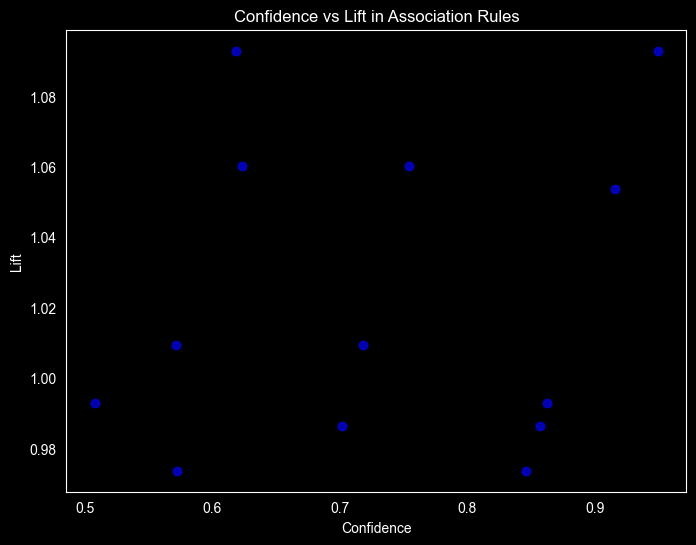

In [23]:
# Scatter plot of confidence vs lift
plt.figure(figsize=(8,6))
plt.scatter(df_ar['confidence'], df_ar['lift'], alpha=0.7, color='b')
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.title('Confidence vs Lift in Association Rules')
plt.grid()
plt.show()

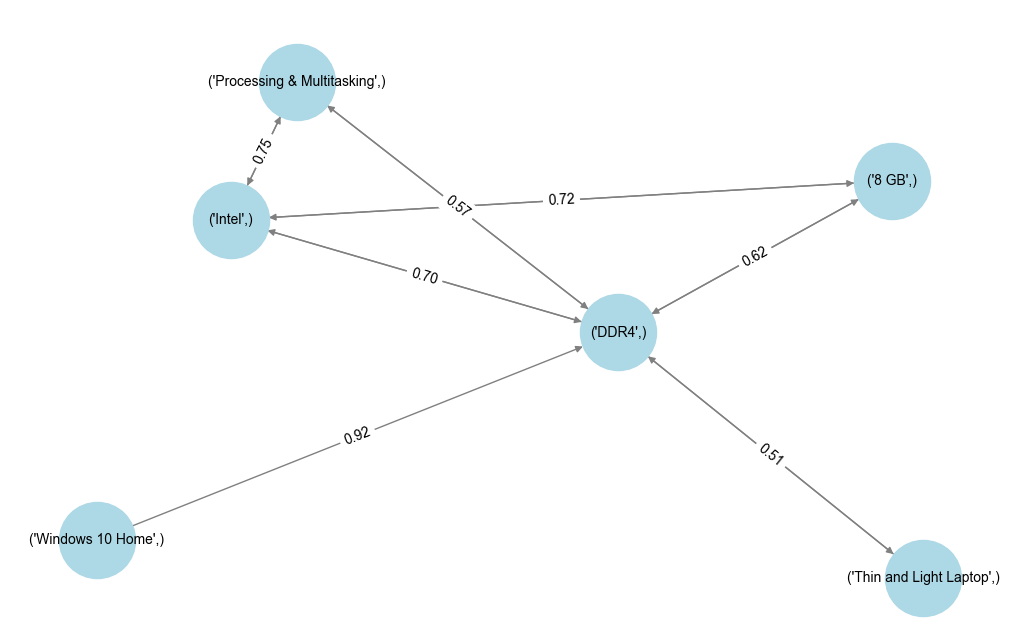

In [24]:
# Visualizing association rules as a network graph
G = nx.DiGraph()
for _, row in df_ar.iterrows():
    G.add_edge(tuple(row['antecedents']), tuple(row['consequents']), weight=row['confidence'])
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=3000, font_size=10)
edge_labels = {(tuple(row['antecedents']), tuple(row['consequents'])): f"{row['confidence']:.2f}"
               for _, row in df_ar.iterrows()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Association Rules Network")
plt.show()